# Database Module End-to-End Demo

This notebook exercises all major functions across the module:
- Database creation, listing, and deletion
- Table creation, listing, insertion, update, range query, and deletion
- Direct B+ Tree and brute-force operations
- Performance comparison of B+ Tree vs brute-force for insert/search/range-query/delete

All sections are runnable in order.

In [1]:
import os
import sys
import random

# Ensure imports work whether the notebook runs from Module_A or Module_A/database.
module_root = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "database" else os.getcwd()
if module_root not in sys.path:
    sys.path.insert(0, module_root)

from database.db_manager import DatabaseManager
from database.table import Table
from database.bplustree import BPlusTree
from database.bruteforce import BruteForceDB
from database.performance import PerformanceAnalyzer

random.seed(42)
print("Module root:", module_root)
print("Imports loaded successfully.")

Module root: c:\Users\dhruv\Desktop\IIT\databases\Assignment 2\CS432_Track1_Submission\Module_A
Imports loaded successfully.


In [2]:
# DatabaseManager workflow: create/list/delete databases and create/list/delete tables.
manager = DatabaseManager()

print("Create databases:", manager.create_database("college"), manager.create_database("analytics"))
print("Create duplicate database (expected False):", manager.create_database("college"))
print("Databases:", manager.list_databases())

student_schema = {"id": int, "name": str, "cgpa": float}
course_schema = {"code": str, "title": str, "credits": int}

print("Create tables:", manager.create_table("college", "students", student_schema, order=5, search_key="id"))
print("Create table:", manager.create_table("college", "courses", course_schema, order=4, search_key="code"))
print("Duplicate table create (expected False):", manager.create_table("college", "students", student_schema))
print("Tables in college:", manager.list_tables("college"))

students = manager.get_table("college", "students")
courses = manager.get_table("college", "courses")
print("Fetched students table type:", type(students).__name__)
print("Fetched courses table type:", type(courses).__name__)

Create databases: True True
Create duplicate database (expected False): False
Databases: ['analytics', 'college']
Create tables: True
Create table: True
Duplicate table create (expected False): False
Tables in college: ['courses', 'students']
Fetched students table type: Table
Fetched courses table type: Table


In [3]:
# Table workflow: validate, insert, get, get_all, update, range_query, delete.
records = [
    {"id": 101, "name": "Aditi", "cgpa": 8.9},
    {"id": 109, "name": "Rohan", "cgpa": 7.8},
    {"id": 115, "name": "Meera", "cgpa": 9.4},
    {"id": 123, "name": "Arjun", "cgpa": 8.1},
]

students.validate_record(records[0])
for record in records:
    inserted_key = students.insert(record)
    print("Inserted student key:", inserted_key)

print("Get id=109:", students.get(109))
print("All students:", students.get_all())

print("Update id=109 (same key):", students.update(109, {"cgpa": 8.0, "name": "Rohan Sharma"}))
print("Move key 123 -> 130:", students.update(123, {"id": 130, "name": "Arjun Rao"}))
print("Range query id 105..140:", students.range_query(105, 140))

print("Delete id=101:", students.delete(101))
print("After deletion:", students.get_all())

Inserted student key: 101
Inserted student key: 109
Inserted student key: 115
Inserted student key: 123
Get id=109: {'id': 109, 'name': 'Rohan', 'cgpa': 7.8}
All students: [{'id': 101, 'name': 'Aditi', 'cgpa': 8.9}, {'id': 109, 'name': 'Rohan', 'cgpa': 7.8}, {'id': 115, 'name': 'Meera', 'cgpa': 9.4}, {'id': 123, 'name': 'Arjun', 'cgpa': 8.1}]
Update id=109 (same key): True
Move key 123 -> 130: True
Range query id 105..140: [{'id': 109, 'name': 'Rohan Sharma', 'cgpa': 8.0}, {'id': 115, 'name': 'Meera', 'cgpa': 9.4}, {'id': 130, 'name': 'Arjun Rao', 'cgpa': 8.1}]
Delete id=101: True
After deletion: [{'id': 109, 'name': 'Rohan Sharma', 'cgpa': 8.0}, {'id': 115, 'name': 'Meera', 'cgpa': 9.4}, {'id': 130, 'name': 'Arjun Rao', 'cgpa': 8.1}]


In [5]:
# Direct BPlusTree usage: insert, search, update, range query, delete, get_all, visualize.
tree = BPlusTree(t=4)

for key in [12, 6, 19, 3, 9, 15, 21, 18]:
    tree.insert(key, {"k": key, "value": f"v_{key}"})

print("Search 15:", tree.search(15))
print("Update 15:", tree.update(15, {"k": 15, "value": "v_15_updated"}))
print("Range query 7..19:", tree.range_query(7, 19))
print("Delete 9:", tree.delete(9))
print("All nodes (leaf order):", tree.get_all())

try:
    dot = tree.visualize_tree()
    print("Graphviz DOT source preview:")
    print("\n".join(dot.source.splitlines()[:10]))
except Exception as exc:
    print("Tree visualization skipped:", exc)

Search 15: {'k': 15, 'value': 'v_15'}
Update 15: True
Range query 7..19: [(9, {'k': 9, 'value': 'v_9'}), (12, {'k': 12, 'value': 'v_12'}), (15, {'k': 15, 'value': 'v_15_updated'}), (18, {'k': 18, 'value': 'v_18'}), (19, {'k': 19, 'value': 'v_19'})]
Delete 9: True
All nodes (leaf order): [(3, {'k': 3, 'value': 'v_3'}), (6, {'k': 6, 'value': 'v_6'}), (12, {'k': 12, 'value': 'v_12'}), (15, {'k': 15, 'value': 'v_15_updated'}), (18, {'k': 18, 'value': 'v_18'}), (19, {'k': 19, 'value': 'v_19'}), (21, {'k': 21, 'value': 'v_21'})]
Graphviz DOT source preview:
digraph BPlusTree {
	node [shape=record]
	2915899779712 [label="{Leaf|3:{'k': 3, 'value': 'v_3'}|6:{'k': 6, 'value': 'v_6'}|12:{'k': 12, 'value': 'v_12'}|15:{'k': 15, 'value': 'v_15_updated'}|18:{'k': 18, 'value': 'v_18'}|19:{'k': 19, 'value': 'v_19'}|21:{'k': 21, 'value': 'v_21'}}"]
}


In [6]:
# Direct BruteForceDB usage.
brute = BruteForceDB()
for key in [2, 5, 8, 11, 14, 17, 20]:
    brute.insert(key)

print("Brute search 11:", brute.search(11))
print("Brute range query 6..18:", brute.range_query(6, 18))
brute.delete(11)
print("Brute search 11 after delete:", brute.search(11))

Brute search 11: True
Brute range query 6..18: [8, 11, 14, 17]
Brute search 11 after delete: False


Benchmarked sizes: 100 from 100 to 99100


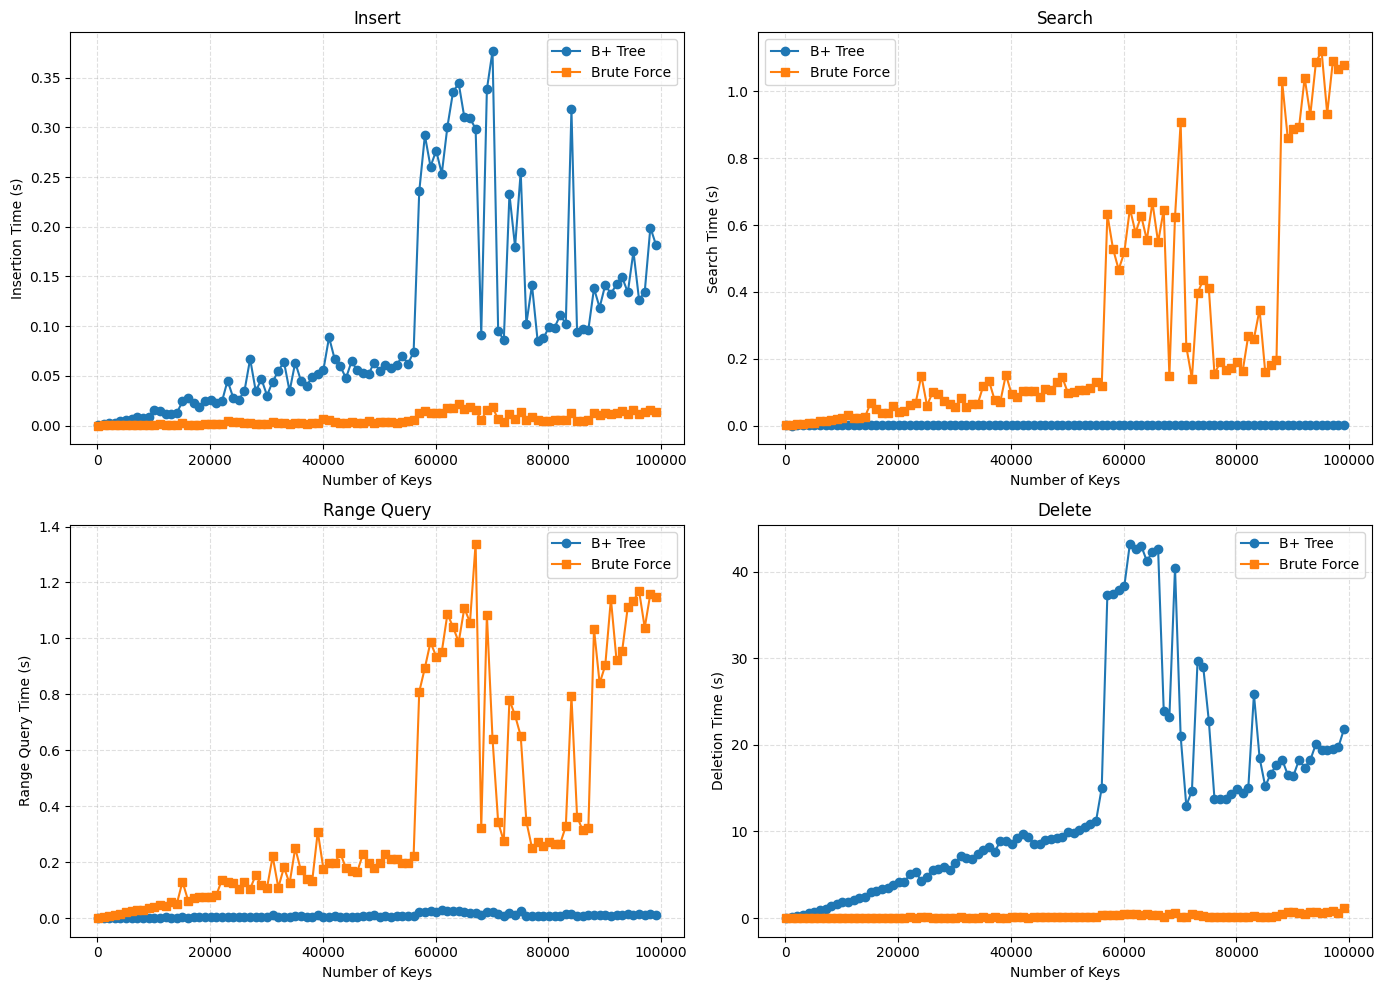

Saved plot: full_range_performance.png


In [7]:
# Performance comparison using configurable random key sizes.
sizes = list(range(100, 100000, 1000))

analyzer = PerformanceAnalyzer(tree_degree=50, seed=42)
results = analyzer.run_tests(
    sizes=sizes,
    search_count=250,
    range_query_count=120,
    delete_count=150,
)

print("Benchmarked sizes:", len(results["sizes"]), "from", results["sizes"][0], "to", results["sizes"][-1])
analyzer.plot_results(results, save_prefix="full_range", show=True)
print("Saved plot: full_range_performance.png")

In [8]:
# Cleanup workflow: delete table and database, and list final state.
print("Delete table courses:", manager.delete_table("college", "courses"))
print("Delete table students:", manager.delete_table("college", "students"))
print("Remaining tables in college:", manager.list_tables("college"))

print("Delete database analytics:", manager.delete_database("analytics"))
print("Delete database college:", manager.delete_database("college"))
print("Final databases:", manager.list_databases())

Delete table courses: True
Delete table students: True
Remaining tables in college: []
Delete database analytics: True
Delete database college: True
Final databases: []
